In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("rice_crop_health_200k.csv")
print(df.head())
print(df.info())

    record_id        date  season       region    rice_variety growth_stage  \
0  RICE000001  2020-05-10  Kharif  West_Bengal  Pusa_Basmati_1     Seedling   
1  RICE000002  2021-07-18  Kharif      Haryana            IR64     Seedling   
2  RICE000003  2021-02-04  Kharif       Punjab          Swarna     Ripening   
3  RICE000004  2020-12-31    Rabi      Haryana  Pusa_Basmati_1    Flowering   
4  RICE000005  2022-06-27    Boro        Assam            IR64     Seedling   

   crop_age_days  field_area_ha   soil_type  soil_pH  ...  \
0            136          10.44       Loamy     7.66  ...   
1             55          18.56   Clay_Loam     5.79  ...   
2            113          16.28    Alluvial     6.22  ...   
3              1          14.29  Silty_Clay     6.49  ...   
4            105           1.09        Clay     6.41  ...   

   actual_yield_ton_ha  msp_INR_per_ton  treatment_cost_INR_ha  \
0                 3.35          21719.0                 3023.0   
1                 7.97    

In [4]:
data = df.copy()

# Drop irrelevant columns
drop_cols = ['record_id', 'date']
data = data.drop(columns=drop_cols, errors='ignore')

In [5]:
# Encode target
target_col = 'intervention_flag' 
encoder=LabelEncoder()
df['intervention_flag']=encoder.fit_transform(df['intervention_flag'])


In [6]:
x = data.drop(target_col, axis=1)
y = data[target_col]

In [7]:
# Encode categorical features
x = pd.get_dummies(x, drop_first=True)

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [9]:
#new input data
input_df = pd.DataFrame(columns=x.columns)
input_df.loc[0] = x.mean()
input_df['soil_type'] = 'Clay'
input_df['soil_pH'] = 5.34
input_df['alert_level']='red'
input_df['field_area_ha']=12.30
input_df['temperature_avg_C']=35
input_df['humidity_pct']=92.3
input_df['rainfall_mm']=0.0

In [10]:
# Encode categorical features
input_df = pd.get_dummies(input_df, drop_first=True)

In [11]:
# Train naive bayes model
from sklearn.naive_bayes import GaussianNB
model1=GaussianNB()
model1.fit(x_train, y_train)


# Predictions
y_pred = model1.predict(x_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100),'\n')

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred),'\n')

#classification report
print('Classification report:\n',classification_report(y_test,y_pred),'\n')


#predict on new data
print('Prediction on new data using naive bayes:')
prediction1=model1.predict(input_df)
if prediction1[0]==0:
    print('Non healthy crop')
else:
    print('Healthy crop')

Accuracy: 91 

Confusion Matrix:
 [[11806  1145]
 [ 2417 24632]] 

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87     12951
           1       0.96      0.91      0.93     27049

    accuracy                           0.91     40000
   macro avg       0.89      0.91      0.90     40000
weighted avg       0.91      0.91      0.91     40000
 

Prediction on new data using naive bayes:
Healthy crop


In [12]:
from sklearn.neighbors import KNeighborsClassifier
model2=KNeighborsClassifier(n_neighbors=5,metric='euclidean')
model2.fit(x_train,y_train)

# Predictions
y_pred = model2.predict(x_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100),'\n')

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred),'\n')

#classification report
print('Classification report:\n',classification_report(y_test,y_pred),'\n')


#predict on new data
print('Prediction on new data using KNN:')
prediction2=model2.predict(input_df)
if prediction2[0]==0:
    print('Non healthy crop')
else:
    print('Healthy crop')

Accuracy: 80 

Confusion Matrix:
 [[ 7857  5094]
 [ 3034 24015]] 

Classification report:
               precision    recall  f1-score   support

           0       0.72      0.61      0.66     12951
           1       0.83      0.89      0.86     27049

    accuracy                           0.80     40000
   macro avg       0.77      0.75      0.76     40000
weighted avg       0.79      0.80      0.79     40000
 

Prediction on new data using KNN:
Healthy crop


Accuracy: 94 

Confusion Matrix:
 [[10602  2349]
 [   55 26994]] 

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.90     12951
           1       0.92      1.00      0.96     27049

    accuracy                           0.94     40000
   macro avg       0.96      0.91      0.93     40000
weighted avg       0.94      0.94      0.94     40000
 



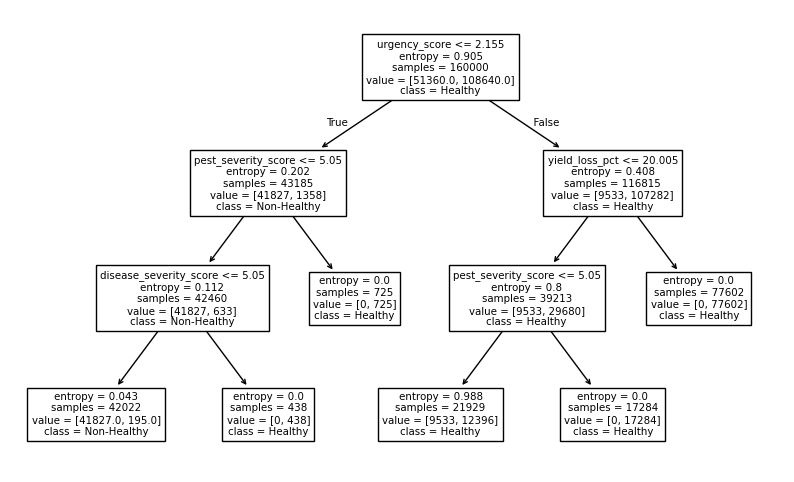

Prediction on new data using decision tree:
Healthy crop


In [13]:
#train decision tree model
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

model3=DecisionTreeClassifier(criterion='entropy',max_depth=3)
model3.fit(x_train,y_train)

# Predictions
y_pred = model3.predict(x_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100),'\n')

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred),'\n')

#classification report
print('Classification report:\n',classification_report(y_test,y_pred),'\n')


plt.figure(figsize=(10,6))
plot_tree(model3,feature_names=x.columns,class_names=['Non-Healthy','Healthy'])
plt.show()

#predict on new data
print('Prediction on new data using decision tree:')
prediction3=model3.predict(input_df)
if prediction3[0]==0:
    print('Non healthy crop')
else:
    print('Healthy crop')

In [14]:
from collections import Counter

print("Ensemble Prediction:")
predictions = [prediction1[0], prediction2[0], prediction3[0]]
ensemble_num = Counter(predictions).most_common(1)[0][0]
if predictions[0]==0:
    print('Non healthy crop')
else:
    print('Healthy crop')

Ensemble Prediction:
Healthy crop


In [15]:
import joblib
joblib.dump(model1, "model_nb.pkl")
joblib.dump(model2, "model_knn.pkl")
joblib.dump(model3, "model_dt.pkl")

['model_dt.pkl']